<a href="https://colab.research.google.com/github/giministk/ml/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Импортируем датасет

In [ ]:
!wget 'https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB' -O test.csv
!wget 'https://drive.google.com/uc?export=download&id=1oDzBtqrXFDnc4ABbAi5hy9UXXT5uVdbD' -O train.csv

df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df.head()

--2026-04-13 10:57:12--  https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB
Resolving drive.google.com (drive.google.com)... 192.178.210.102, 192.178.210.101, 192.178.210.138, ...
Connecting to drive.google.com (drive.google.com)|192.178.210.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download [following]
--2026-04-13 10:57:12--  https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.179.132, 2607:f8b0:4001:c68::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.179.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28629 (28K) [application/octet-stream]
Saving to: ‘test.csv’

test.csv            100%[===================>]  27.96K  --.-KB/s    i

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
test_df.info()
test_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### 4. Сформируем обучающую и тестовую выборки:


In [ ]:
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df.drop('Cabin', axis=1, inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)

X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived', axis=1), df['Survived'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

/tmp/ipykernel_6695/3233024665.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


((596, 11), (295, 11))

### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [ ]:
X_train2 = X_train.drop(["Name", "Ticket", "PassengerId"], axis=1)
X_test2 = X_test.drop(["Name", "Ticket", "PassengerId"], axis=1)

X_train2.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
6,1,54.000000,0,0,51.8625,True,False,True
718,3,29.699118,0,0,15.5000,True,True,False
685,2,25.000000,1,2,41.5792,True,False,False
73,3,26.000000,1,0,14.4542,True,False,False
882,3,22.000000,0,0,10.5167,False,False,True


### 6. Построение базовой модели:

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train2, y_train)
y_pred = model.predict(X_test2)

### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


def conf_matrix(y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title('Матрица ошибок')
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()
  print(classification_report(y_test, y_pred))

#### 7.2. Оцените точность модели:

(295,) (295,)


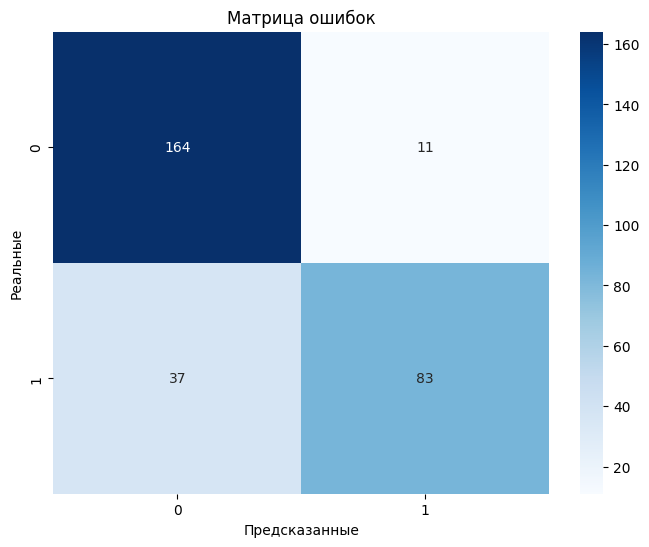

              precision    recall  f1-score   support

           0       0.82      0.94      0.87       175
           1       0.88      0.69      0.78       120

    accuracy                           0.84       295
   macro avg       0.85      0.81      0.82       295
weighted avg       0.84      0.84      0.83       295



In [ ]:
print(y_pred.shape, y_test.shape)
conf_matrix(y_pred, y_test)

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)], 'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)]}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=300,
    scoring='accuracy',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train2, y_train)

rcv_best_params = rf_rcv.best_params_
print(f"Лучшие параметры: {rcv_best_params}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 100 is smaller than n_iter=300. Running 100 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Лучшие параметры: {'n_estimators': 100, 'max_leaf_nodes': 12}


#### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

if rcv_best_params['n_estimators'] >= 6:
  n_estimators = [int(x) for x in range(rcv_best_params['n_estimators']-5, rcv_best_params['n_estimators']+6)]
else:
  n_estimators = [int(x) for x in range(1, 10)]
if rcv_best_params['max_leaf_nodes'] >= 7:
  max_leaf_nodes = [int(i) for i in range(rcv_best_params['max_leaf_nodes']-5, rcv_best_params['max_leaf_nodes']+6)]
else:
  max_leaf_nodes = [int(i) for i in range(2, 11)]

random_grid = {
    'n_estimators': n_estimators,
    'max_leaf_nodes': max_leaf_nodes,
}

rf_cv = GridSearchCV(
    estimator=model,        # модель для настройки
    param_grid=param_grid,  # словарь с параметрами для перебора
    scoring="accuracy",      # метрика для оценки качества моделей
    cv=5,                    # количество фолдов для кросс-валидации
    verbose=0,               # уровень детализации вывода
    n_jobs=-1                # использование всех доступных ядер процессора
)

rf_cv.fit(X_train2, y_train)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_
print(f"Лучшие параметры: {best_params}")

### 9. Комплексная оценка точности лучшей модели:

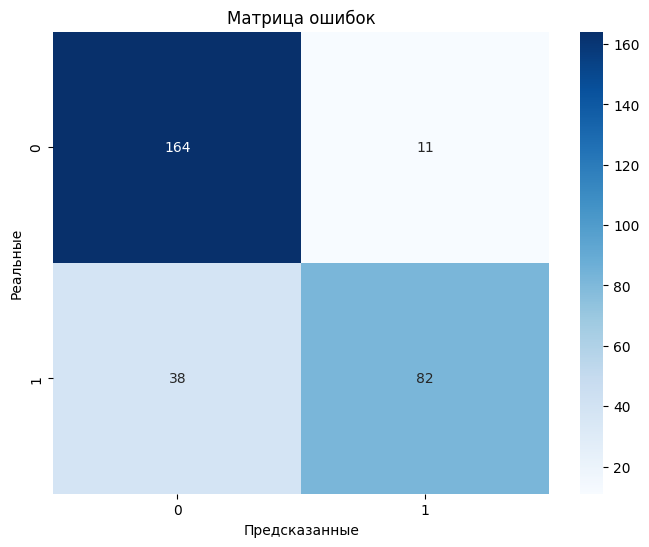

              precision    recall  f1-score   support

           0       0.81      0.94      0.87       175
           1       0.88      0.68      0.77       120

    accuracy                           0.83       295
   macro avg       0.85      0.81      0.82       295
weighted avg       0.84      0.83      0.83       295



In [ ]:
best_model = RandomForestClassifier(n_estimators=100, max_leaf_nodes=12, random_state=1)
best_model.fit(X_train2, y_train)
y_pred = best_model.predict(X_test2)
conf_matrix(y_pred, y_test)

## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

elnet = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.99)
elnet.fit(X_train2, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(l1_ratio=0.99, penalty='elasticnet', solver='saga')

## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [ ]:
def predictor(model):
  res = {}
  print("Введите следующие признаки:")

  while True:
    inp = int(input("Класс пассажира (1-3): "))
    if inp in range(1,4):
      res['Pclass'] = inp
      break
    else:
      print('Введено некорректное значение')

  res['Age'] = int(input("Возраст (0-inf): "))
  res['SibSp'] = int(input("Количество родных партнеров/братьев/сестер на борту (0-inf): "))
  res['Parch'] = int(input("Кол-во родных родителей/детей на борту (0-inf): "))
  res['Fare'] = int(input("Плата за проезд (0-inf): "))

  while True:
    inp = input("Пол (male/female): ")
    if inp == 'male':
      res['Sex_male'] = True
      break
    elif inp == 'female':
      res['Sex_male'] = False
      break
    else:
      print('Введено некорректное значение')

  while True:
    inp = input("Из какого города отправились (S/C/Q): ")
    if inp == 'S':
      res['Embarked_Q'] = False
      res['Embarked_S'] = True
      break
    elif inp == 'C':
      res['Embarked_Q'] = False
      res['Embarked_S'] = False
      break
    elif inp == 'Q':
      res['Embarked_Q'] = True
      res['Embarked_S'] = False
      break
    else:
      print('Введено некорректное значение')

  res = pd.DataFrame([res])
  pred = model.predict(res)
  if pred[0] == 0:
    print('\nМодель предсказал, что вы не выживете...')
  if pred[0] == 1:
    print('\nМодель предсказал, что вы выживете!')

predictor(model)

Введите следующие признаки:
Класс пассажира (1-3): 2
Возраст (0-inf): 26
Количество родных партнеров/братьев/сестер на борту (0-inf): 1
Кол-во родных родителей/детей на борту (0-inf): 0
Плата за проезд (0-inf): 30
Пол (male/female): female
Из какого города отправились (S/C/Q): C

Модель предсказал, что вы выживете!


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [ ]:
# Ваш код
import kagglehub
import pandas as pd

kagglehub.dataset_download("mohansacharya/graduate-admissions")
df = pd.read_csv('/kaggle/input/graduate-admissions/Admission_Predict.csv')

Using Colab cache for faster access to the 'graduate-admissions' dataset.


In [ ]:
df = df.drop('Serial No.', axis=1)
display(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.1 KB


None

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Chance of Admit ', axis=1), df['Chance of Admit '], test_size = 0.25, random_state = 1)
X_train.shape, X_test.shape

((300, 7), (100, 7))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=1)
model.fit(X_train, y_train)
model

RandomForestRegressor(max_depth=5, n_estimators=50, random_state=1)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)

print(f"R2 score: {r2_score(y_test, y_pred)}, MSE: {mean_squared_error(y_test, y_pred)}")

R2 score: 0.7720763062838172, MSE: 0.00519364022778723


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

#оставлен только RandomizedSearchCV, т.к. GridSearch работал слишком долго
max_depth = [int(i) for i in np.linspace(start=1, stop=50, num=10)]
max_depth.append(None)
param_grid = {'n_estimators': [int(x) for x in np.linspace(start=50, stop=100, num=10)], 'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=50, num=10)], 'max_depth': max_depth}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    random_state=1,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
rcv_best_params = rf_rcv.best_params_
print(f'Лучшая модель: {best_model}')

Лучшая модель: RandomForestRegressor(max_depth=33, max_leaf_nodes=7, n_estimators=61,
                      random_state=1)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
best_model = RandomForestRegressor(max_depth=33, max_leaf_nodes=7, n_estimators=61,
                      random_state=1)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"R2 score: {r2_score(y_test, y_pred)}, MSE: {mean_squared_error(y_test, y_pred)}")

R2 score: 0.7597298584729613, MSE: 0.005474975647441252


## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [ ]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [ ]:
import pandas as pd

data = pd.read_csv('data/dog_food.csv')

In [ ]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('Spoiled', axis=1), data['Spoiled'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((328, 4), (162, 4))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
max_depth = [int(i) for i in np.linspace(start=1, stop=50, num=8)]
max_depth.append(None)
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=300, num=8)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=80, num=8)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
print(f'Лучшая модель: {best_model}')

Лучшая модель: RandomForestClassifier(max_depth=22, max_leaf_nodes=57, n_estimators=157,
                       random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(max_depth=22, max_leaf_nodes=57, n_estimators=157,
                       random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test) # предсказываем какие партии испортятся
fin = X_test.copy()
fin['Spoiled'] = pred # создаем колонку для результатов предсказания
fin = fin[fin['Spoiled'] != 0] # убираем все хорошие партии
print("Чем больше значение, тем больше влияние консерванта на партию")
for i in fin.columns:
  if i != 'Spoiled':
    print(f'{i}: {fin[i].sum()}')

Чем больше значение, тем больше влияние консерванта на партию
A: 294
B: 269
C: 615.0
D: 294


Результатом нашего предсказания стала консервант C